In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [20]:
df=pd.read_csv("..//Data/bank.csv")

In [21]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


loaded the dataset, isFraud column is the target value and all others are features 

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


key- the decision tree and random fores need float/int, can not work with str.

In [23]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

there is no empty/null values

<Axes: xlabel='type'>

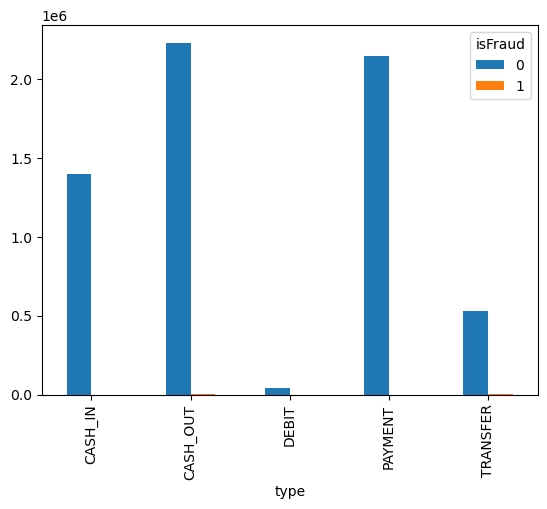

In [24]:
grouped = df.groupby(['type','isFraud']).size().unstack(fill_value=0)
grouped.plot(kind='bar')

there are little frauds compare to normal transaction, as of payment type, it seems cash_out and transfer have some frauds, just a little orange. 

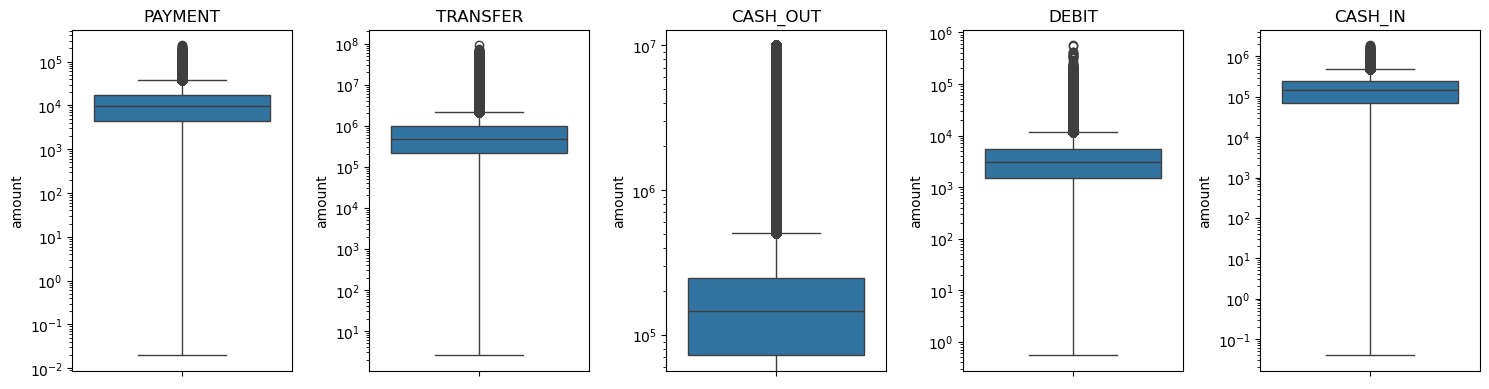

In [25]:

types = df["type"].unique()

fig, axes = plt.subplots(1, len(types), figsize=(15, 4))

for i, t in enumerate(types):
    sns.boxplot(
        data=df[df["type"] == t],
        y="amount",
        ax=axes[i]
    )
    axes[i].set_title(t)
    axes[i].set_yscale("log")  # optional log scale

plt.tight_layout()
plt.show()


each payment type have extreme values, need to scale or maybe some other ways to work the outliers. 

In [ ]:
dft = df.pivot_table(index='type',columns='isFraud',aggfunc='size',fill_value=0)
dft

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


The frauds only in cash_out and transfer

In [27]:
dff=df[df['isFraud']==1]
dff.info()

<class 'pandas.DataFrame'>
Index: 8213 entries, 2 to 6362619
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            8213 non-null   int64  
 1   type            8213 non-null   str    
 2   amount          8213 non-null   float64
 3   nameOrig        8213 non-null   str    
 4   oldbalanceOrg   8213 non-null   float64
 5   newbalanceOrig  8213 non-null   float64
 6   nameDest        8213 non-null   str    
 7   oldbalanceDest  8213 non-null   float64
 8   newbalanceDest  8213 non-null   float64
 9   isFraud         8213 non-null   int64  
 10  isFlaggedFraud  8213 non-null   int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 770.0 KB


about 8000 fraud among 6 million transactions. 0.133%

In [28]:
(dff['step']==1).value_counts()

step
False    8197
True       16
Name: count, dtype: int64

just trying to understand how important is step feature to fraud indication. 

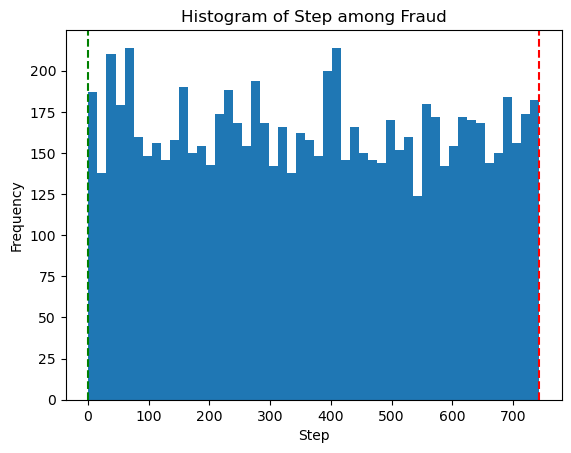

In [29]:
dfmin=df['step'].min()
dfmax=df['step'].max()
plt.hist(dff['step'], bins=50)
plt.axvline(dfmin, color='green', linestyle='--', label=f'Min: {dfmin}')
plt.axvline(dfmax, color='red', linestyle='--', label=f'Max: {dfmax}')
plt.xlabel('Step')
plt.ylabel('Frequency')
plt.title('Histogram of Step among Fraud')
plt.show()

it seems overvall equally spread of fraud in steps feature, while also within the min and max from the whole dataset. So- steps are not relavent to be a feature for the draud detection.

Text(0, 0.5, 'Count')

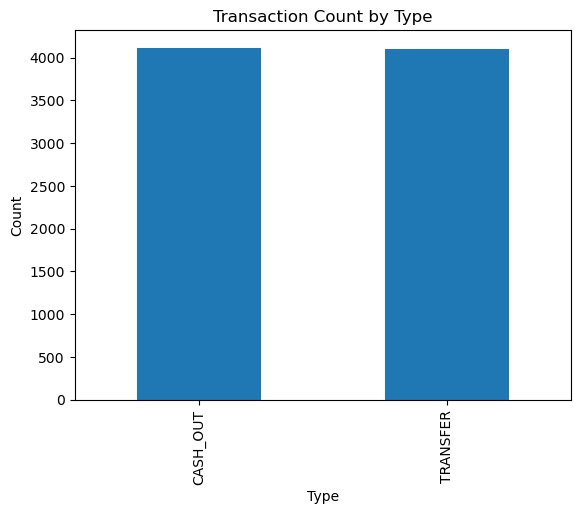

In [30]:
groupedf = dff.groupby('type').size()
groupedf.plot(kind='bar')
plt.title('Transaction Count by Type')
plt.xlabel('Type')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

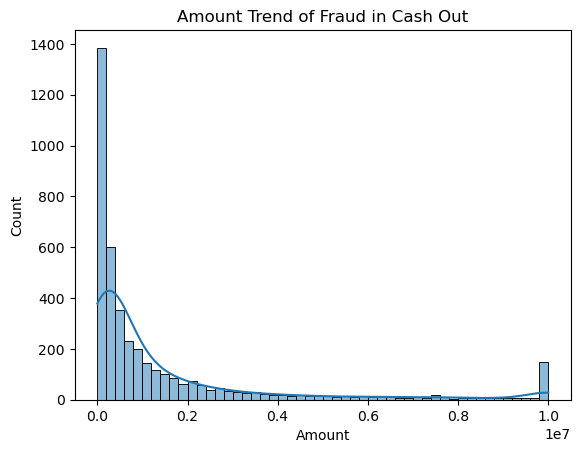

In [ ]:
dffc=dff[dff['type']=='CASH_OUT'] # create a subset among df-fraud just for cashout type
sns.histplot(dffc['amount'], bins=50, kde=True)
plt.title('Amount Trend of Fraud in Cash Out')
plt.xlabel('Amount')
plt.ylabel('Count')



the Cash_Out fraud subest have right skewed distribution, while have a spike in the last set of data. 

In [32]:
counts, bin_edges = np.histogram(dffc['amount'], bins=50)

last_bin = (bin_edges[-2], bin_edges[-1])
dffcv=dffc[dffc['amount']>=9800000]
(dffcv['amount']==dffcv['oldbalanceOrg']).value_counts()


True    147
Name: count, dtype: int64

It seems that in the last bin, the highest amount range, the fraud amount is equal to the available balance of the orignal account.

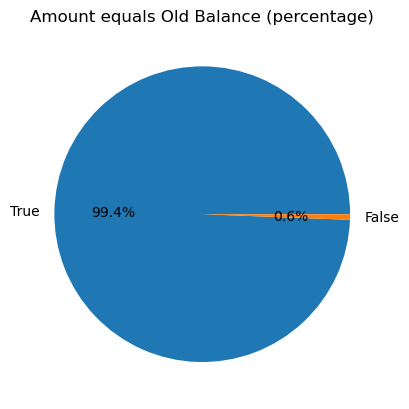

In [47]:
dffcp=(dffc['amount'] == dffc['oldbalanceOrg']).value_counts(normalize=True) * 100
dffcp.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')  # removes the default y-label
plt.title('Amount equals Old Balance (percentage)')
plt.show()

it seems 99% of fraud from Cash_Out have the amount = orignal account balance

Text(0, 0.5, 'Count')

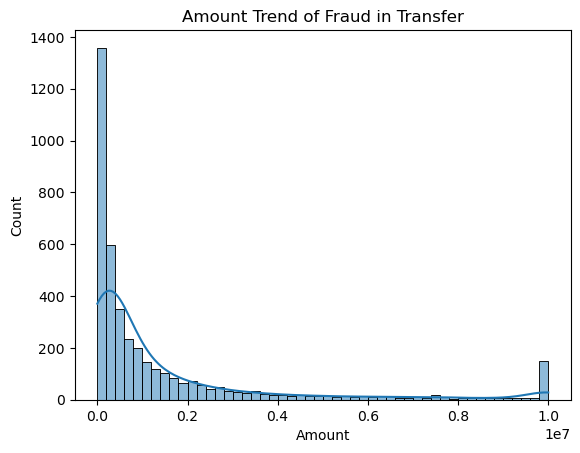

In [ ]:
dfft=dff[dff['type']=='TRANSFER'] # create a subset among df-fraud just for transfer type
sns.histplot(dfft['amount'], bins=50, kde=True)
plt.title('Amount Trend of Fraud in Transfer')
plt.xlabel('Amount')
plt.ylabel('Count')

the fraud in transfer type shows the same pattern as to cash_out type.

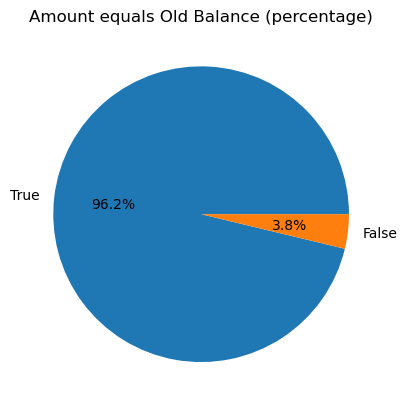

In [48]:
dfftp=(dfft['amount'] == dfft['oldbalanceOrg']).value_counts(normalize=True) * 100
dfftp.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')  # removes the default y-label
plt.title('Amount equals Old Balance (percentage)')
plt.show()

Same pattern here, the tansfer subset of frauds have 96% which the transfer amount = the available balance. 

In [36]:
dfft.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.0,0.0,1,0
251,1,TRANSFER,2806.00,C1420196421,2806.00,0.0,C972765878,0.0,0.0,1,0
680,1,TRANSFER,20128.00,C137533655,20128.00,0.0,C1848415041,0.0,0.0,1,0
969,1,TRANSFER,1277212.77,C1334405552,1277212.77,0.0,C431687661,0.0,0.0,1,0
1115,1,TRANSFER,35063.63,C1364127192,35063.63,0.0,C1136419747,0.0,0.0,1,0
1869,1,TRANSFER,25071.46,C669700766,25071.46,0.0,C1384210339,0.0,0.0,1,0
2301,1,TRANSFER,235238.66,C1872047468,235238.66,0.0,C116289363,0.0,0.0,1,0
3059,2,TRANSFER,1096187.24,C1093223281,1096187.24,0.0,C2063275841,0.0,0.0,1,0
3162,2,TRANSFER,963532.14,C1440057381,963532.14,0.0,C268086000,0.0,0.0,1,0
3271,2,TRANSFER,14949.84,C140702728,14949.84,0.0,C634210724,0.0,0.0,1,0


In [37]:
((df['amount'] == df['oldbalanceOrg'])).value_counts(normalize=True) * 100

False    99.873731
True      0.126269
Name: proportion, dtype: float64

In [38]:
(dff['amount'] == dff['oldbalanceOrg']).value_counts(normalize=True) * 100

True     97.820528
False     2.179472
Name: proportion, dtype: float64

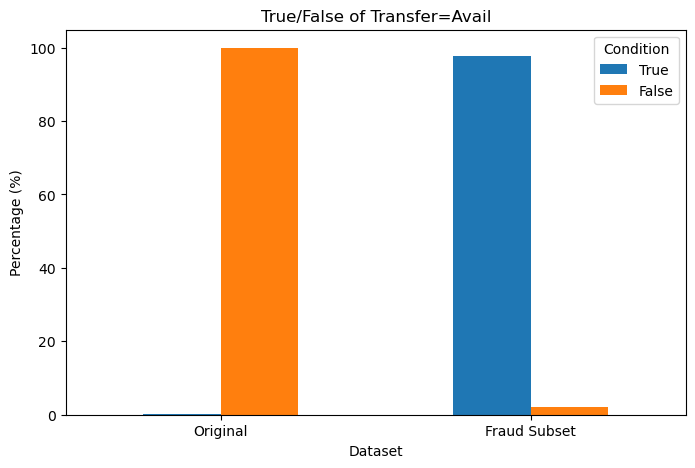

In [60]:
df_counts = (df['amount'] == df['oldbalanceOrg']).value_counts(normalize=True) * 100
dff_counts = (dff['amount'] == dff['oldbalanceOrg']).value_counts(normalize=True) * 100

# Align index
df_counts = df_counts.reindex([True, False], fill_value=0)
dff_counts = dff_counts.reindex([True, False], fill_value=0)

# Create DataFrame (transpose for your layout)
plot_df = pd.DataFrame({
    'True': [df_counts[True], dff_counts[True]],
    'False': [df_counts[False], dff_counts[False]]
}, index=['Original', 'Fraud Subset'])

# Plot
plot_df.plot(kind='bar', figsize=(8, 5))

plt.xlabel('Dataset')
plt.ylabel('Percentage (%)')
plt.title('True/False of Transfer=Avail')
plt.xticks(rotation=0)
plt.legend(title='Condition')

plt.show()




Over 96% of transfer fraud had the same pattern as cashout.
While over the original data, only .13% have transfer = the balance.
Consider creating a new feature 1-0 for mathing amount. 
So it can remove the large difference in amount-> focus on the trend instead. 

In [39]:
(df['newbalanceOrig']==0).value_counts(normalize=True) * 100

newbalanceOrig
True     56.730812
False    43.269188
Name: proportion, dtype: float64

In [40]:
(dff['newbalanceOrig']==0).value_counts(normalize=True) * 100

newbalanceOrig
True     98.051869
False     1.948131
Name: proportion, dtype: float64

The fraud have 98% rate leave the account empty, - the normal transactions is about 50/50.

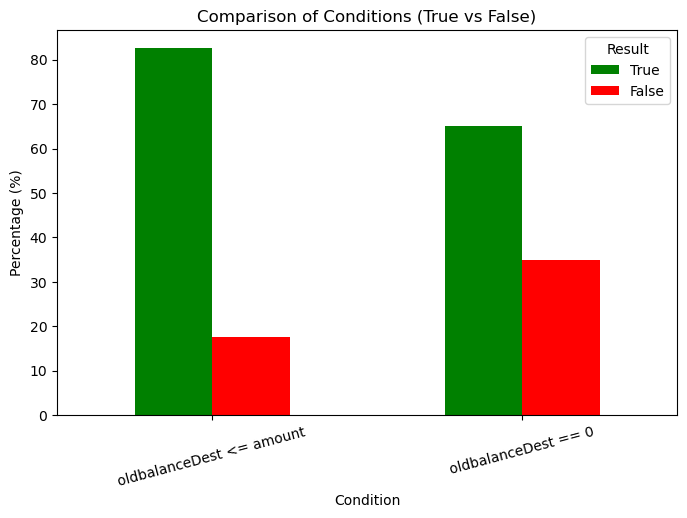

In [61]:
d1=(dff['oldbalanceDest']<=dff['amount']).value_counts(normalize=True) * 100
d2=(dff['oldbalanceDest']==0).value_counts(normalize=True) * 100

d1 = d1.reindex([True, False], fill_value=0)
d2 = d2.reindex([True, False], fill_value=0)

# Create DataFrame (grouped by condition)
plot_df = pd.DataFrame({
    'True': [d1[True], d2[True]],
    'False': [d1[False], d2[False]]
}, index=['oldbalanceDest <= amount', 'oldbalanceDest == 0'])

# Plot
plot_df.plot(kind='bar', figsize=(8, 5), color=['green', 'red'])

plt.xlabel('Condition')
plt.ylabel('Percentage (%)')
plt.title('Comparison of Conditions (True vs False)')
plt.xticks(rotation=15)
plt.legend(title='Result')

plt.show()

In [42]:
(dff['isFraud']==dff['isFlaggedFraud']).value_counts(normalize=True) * 100

False    99.805187
True      0.194813
Name: proportion, dtype: float64

the flagged is somewhat useless, only ided 0.19% among the true fraud.

In [43]:
(dff['newbalanceDest']==0).value_counts(normalize=True) * 100

newbalanceDest
False    50.188725
True     49.811275
Name: proportion, dtype: float64

In [44]:
dest_counts = dff['nameDest'].value_counts()
dest_counts_a=df['nameDest'].value_counts()
print("Top 10 ID count in Fraud")
print(dest_counts)

print("\nTop 10 ID count overall")
print(dest_counts_a)

Top 10 ID count in Fraud
nameDest
C410033330     2
C803116137     2
C904300960     2
C1013511446    2
C2020337583    2
              ..
C776919290     1
C1881841831    1
C1365125890    1
C2080388513    1
C873221189     1
Name: count, Length: 8169, dtype: int64

Top 10 ID count overall
nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64


it seems the fraud accounts most used is twice, so the frequency of ID is somewhat not important. 

1- Step is not important- the distrubiton of steps in fraud is almost euqlly
2- type- the fraud happens in Cash_out and Transfer, but its just this set though
3- amount- 97% of fraud have amount=avaialbe balance, and 99% of whole datasets does not follow this trend. so can create a boolean feature for amount-balance to avoid the outliers in amount. 
4- ids does not matter(or matters, more often less fraud?)
5- newbalanceorig- the overall have half/half while the fraud subset have 98% for the balance to be 0 
6- isFraudFlagged- useless